# NEOFC: Create overview plots

In [1]:
from pathlib import Path 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib.gridspec import GridSpec
from PIL import Image
import imageio.v2 as iio
import seaborn as sn
import netplotbrain
from tqdm.auto import tqdm

from utils import merge_cmaps, get_ref_data

from mapconn.plot import plot_mapconn_curve

# working directory
wd = Path.cwd() 
print(wd)

# general vars
from utils import (REF_GROUPS, REF_GROUPS_COLORS, REF_GROUPNAMES_PET, REF_NAMES_PET, REF_GROUPS_PET,
                   PARC_DEFAULT, PARCS_ALL, PARCS_CX,
                   MEASURES_ALL, MEASURES_NICE, MEG_MEASURES_ALL, MEG_FQBANDS)

# colors
colors = REF_GROUPS_COLORS[1:]
colors_maps = [c for i, v in enumerate(REF_GROUPS_PET.values()) for c in [colors[i]]*len(v)]

colors_by_map = {}
for group, color in zip(REF_GROUPS, REF_GROUPS_COLORS):
    for m in REF_GROUPS[group]:
        colors_by_map[m] = color

/Users/llotter/projects/mapfc


##  Data

### MapConn data: HCP-YA MRI

In [2]:
mfc_ya_mri = pd.read_pickle(wd / "data_deriv" / "mapconn" / "hcp_ya_mri" / f"parc-Schaefer200_dset-pet_mapconn.pkl.gz")

### PET reference data

In [3]:
data_ref = get_ref_data("pet", "Schaefer200")
data_ref

Loading parcellated pet data, standardized=True


,hemi-L_div-Vis_lab-1,hemi-L_div-Vis_lab-2,hemi-L_div-Vis_lab-3,hemi-L_div-Vis_lab-4,hemi-L_div-Vis_lab-5,hemi-L_div-Vis_lab-6,hemi-L_div-Vis_lab-7,hemi-L_div-Vis_lab-8,hemi-L_div-Vis_lab-9,hemi-L_div-Vis_lab-10,...,hemi-R_div-Default_lab-PFCm+1,hemi-R_div-Default_lab-PFCm+2,hemi-R_div-Default_lab-PFCm+3,hemi-R_div-Default_lab-PFCm+4,hemi-R_div-Default_lab-PFCm+5,hemi-R_div-Default_lab-PFCm+6,hemi-R_div-Default_lab-PFCm+7,hemi-R_div-Default_lab-PCC+1,hemi-R_div-Default_lab-PCC+2,hemi-R_div-Default_lab-PCC+3
5HT1a,0.242521,-1.012039,0.103727,-1.298651,-1.664068,-0.337140,-2.487159,0.259029,-1.484782,-1.746785,...,0.816689,0.829252,-0.365888,0.245154,-0.079351,-0.149584,-0.495787,-0.831653,-0.278468,-0.442881
5HT1b,-1.032709,-0.281828,-0.142056,0.009959,0.558745,-2.702971,3.068384,0.249281,0.431451,2.601738,...,-0.701319,-0.064954,-1.336322,0.263009,0.592660,0.781236,0.734859,-0.837514,-0.154833,-0.098862
5HT2a,-0.046030,-0.334491,0.437479,-0.454518,-0.104702,-2.292043,0.141766,0.735451,-0.037308,0.584442,...,-0.180471,-0.357249,-2.654473,0.467877,0.663986,0.560142,0.404215,-0.752663,1.199359,0.435919
5HT4,-0.031954,-0.744829,0.573733,-1.319910,-1.706253,-1.136569,-2.265509,0.746292,-1.083537,-1.376613,...,0.384866,0.120564,-1.304104,0.096612,-0.027086,-0.252184,-0.504667,-0.281662,0.843254,0.506718
5HT6,-0.375488,-0.142426,0.595812,-1.227212,-0.058230,-3.703124,0.312230,0.956246,0.184458,0.804090,...,-0.329729,0.089328,-1.763844,0.612178,0.108492,0.909910,0.582685,-0.601393,0.601853,1.036586
5HTT,0.527928,-0.242480,-0.560377,0.309124,-0.425065,0.702842,0.224177,0.066336,-0.267479,1.327270,...,0.884289,0.577007,1.324297,-0.707523,-1.090125,-1.086527,-1.271068,0.379727,0.303422,-0.598683
A4B2,0.071017,-0.222817,-0.602551,-1.241972,-1.677564,-1.627673,-1.872931,0.224154,-0.307094,-0.526523,...,0.076027,0.619104,-0.052257,0.353620,-0.588126,1.625636,0.432378,-0.282502,1.000629,0.635378
CB1,-0.283527,-0.557762,-0.018422,-1.889326,-0.337344,-2.346905,-1.702054,-0.711373,-1.251877,-1.799636,...,1.754007,1.519663,0.221042,1.424205,0.655761,0.587635,0.287522,-1.374018,-0.305290,0.158155
CMRglu,0.231438,0.088432,-0.356602,0.709631,-0.759343,-0.942125,0.646456,0.325498,-0.518922,1.786835,...,0.471460,0.575172,-1.179825,-0.600246,-1.315322,0.704625,0.240740,1.345199,2.914683,1.968953
D1,1.301538,0.006823,-0.161505,0.544701,-1.558446,0.126047,-0.191536,-0.320255,-1.437981,1.131517,...,2.205274,1.885736,0.106177,0.387039,-0.768934,0.296428,-0.360103,1.201099,1.878827,1.010202


## Plot overview and animation

### Plot functions

/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_8546/2480810156.py:90: RuntimeWarning: Mean of empty slice
  matrix = np.nanmean(np.stack(mfc_ya_mri["pearson"]["all"]["1"].get_connectivity_matrices(flat=False)), axis=0)


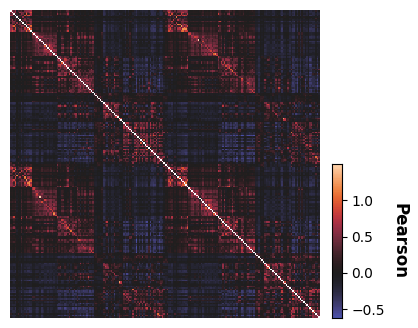

In [4]:
def plot_matrix(matrix, matrix_upper=None, ax=None, cmap="icefire", x_label="", categories=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    
    # prep data
    matrix = np.tril(matrix)
    mask = np.triu(np.ones_like(matrix))
    if matrix_upper is not None:
        matrix_upper = np.triu(matrix_upper)
        mask_upper = np.tril(np.ones_like(matrix))
    
    # cbar axis
    if matrix_upper is None:
        cax = ax.inset_axes((0, -0.04, 1/2, 0.03))
    else:
        cax = ax.inset_axes((1.04, 0, 0.03, 1/2)) 
        
    # plot
    sn.heatmap(
        matrix, 
        mask=mask, 
        cmap=cmap, 
        center=0, 
        #vmax=0.3,
        ax=ax, 
        xticklabels=False, 
        yticklabels=False, 
        cbar_ax=cax,
        cbar_kws={"orientation": "horizontal" if matrix_upper is None else "vertical"}
    )
    
    # layout
    sn.despine(ax=ax, left=False, bottom=False, right=True, top=True)
    sn.despine(ax=cax, left=False, bottom=False, right=False, top=False)
    if matrix_upper is None:
        cax.set_xlabel(x_label, fontsize=12, fontweight="bold", labelpad=12)
    else:
        cax.set_ylabel(x_label, fontsize=12, fontweight="bold", rotation=-90, va="bottom")
    
    # plot upper
    if matrix_upper is not None:
        sn.heatmap(
        matrix_upper, 
        mask=mask_upper, 
        cmap=cmap, 
        center=0, 
        #vmax=0.3,
        ax=ax, 
        xticklabels=False, 
        yticklabels=False, 
        cbar=False
    )
        
    if categories is not None:
        if len(categories) != matrix.shape[0]:
            raise ValueError("Length of categories must match number of rows/columns in matrix")
        categories_unique = list(set(categories))
        colors = sn.color_palette("tab10", len(categories_unique))
        ax_cat = ax.inset_axes([-0.04, 0, 0.03, 1])
        ax_cat.set_ylim(ax.get_ylim())
        ax_cat.set_xticks([])
        ax_cat.set_yticks([])
        cat_last = ""
        for i, cat in enumerate(categories):
            patch = plt.Rectangle(
                (0, i ), #if loc == "left" else len(categories) - i - 1
                1, 
                1, 
                facecolor=colors[categories_unique.index(cat)], 
                alpha=1,
                label=cat if cat != cat_last else None
            )
            ax_cat.add_patch(patch)
            cat_last = cat
                
        # legend
        handles, labels = ax_cat.get_legend_handles_labels()
        labels, unique_idc = np.unique(labels, return_index=True)
        handles = [handles[i] for i in unique_idc]
        ax.legend(
            handles, 
            labels,
            loc="upper right", 
            bbox_to_anchor=(-0.05, 1), 
            frameon=False, 
            title="Network"
        )


matrix = np.nanmean(np.stack(mfc_ya_mri["pearson"]["all"]["1"].get_connectivity_matrices(flat=False)), axis=0)
plot_matrix(matrix, matrix, x_label="Pearson")

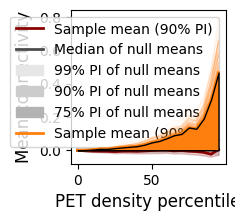

In [5]:
def plot_mapconn(mapconn, map, ax=None, color_obs="tab:orange", color_inv="darkred", 
                 title="", xlabel="PET density percentile", ylabel="Mean connectivity",
                 plot_auc=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(2, 2))
    
    # data
    mfc_obs = mapconn.get_curves(maps=map)
    mfc_inv = mapconn.get_inverse_curves(maps=map)
    mfc_null = mapconn.get_null_curves_dist(maps=map)
    
    # plot inverse
    plot_mapconn_curve(
        mfc_inv,
        mfc_null,
        ax=ax,
        color=color_inv,
        plot_individual=False,
        alpha=1,
    )
    
    # plot observed
    plot_mapconn_curve(
        mfc_obs,
        ax=ax,
        color=color_obs,
        plot_individual=True,
        alpha=1,
    )
    
    if plot_auc:    
        mfc_obs_mean = mfc_obs.mean(axis=0)
        ax.fill_between(
            y1=[0]*len(mfc_obs_mean),
            y2=mfc_obs_mean,
            x=mfc_obs_mean.index.get_level_values("pct"),
            color=color_obs,
            lw=1,
            ec="k",
            alpha=1,
            zorder=1000
        )
    
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)


plot_mapconn(mfc_ya_mri["pearson"]["all"]["1"], "NET", plot_auc=True)
#plt.legend().set_visible(False)

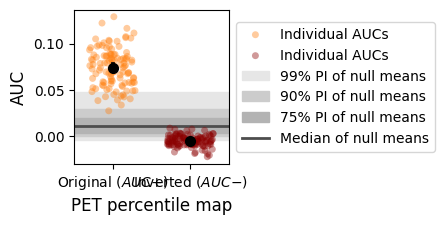

In [6]:
def plot_auc(mapconn, map, ax=None, color_obs="tab:orange", color_inv="darkred", 
             title="", xlabel="PET percentile map", ylabel="AUC"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(2, 2))
    
    # data
    auc = pd.concat(
        [mapconn.get_stats(maps=map)["auc"], mapconn.get_inverse_stats(maps=map)["auc"]],
        axis=1
    )
    auc.columns = ["Original ($AUC\t{+}$)", "Inverted ($AUC\t{-}$)"]
    auc_null = mapconn.get_null_stats_dist(maps=map)["auc"]
    
    # plot observed/inverse
    np.random.seed(7)
    sn.stripplot(
        data=auc.melt(),
        x="variable",
        y="value",
        ax=ax,
        hue="variable",
        palette={"Original ($AUC\t{+}$)": color_obs, "Inverted ($AUC\t{-}$)": color_inv},
        alpha=0.4,
        jitter=0.3,
        label="Individual AUCs",
    )
    sn.pointplot(
        data=auc.melt(),
        x="variable",
        y="value",
        ax=ax,
        color="k",
        linestyle="none",
        alpha=1,
        markersize=6,
        zorder=100,
    )
        
    for p1, p2, c in [("1%", "99%", "0.9"), ("10%", "90%", "0.8"), ("25%", "75%", "0.7")]:
        ax.fill_between(
            [-1,2],
            auc_null.loc[p1],
            auc_null.loc[p2],
            color=c,
            alpha=1,
            label=f"{p2} PI of null means",
            zorder=-1001
        )
    ax.plot(
        [-1,2],
        [auc_null.loc["50%"]] * 2,
        color="0.3",
        alpha=1,
        lw=2,
        label=f"Median of null means",
        zorder=-1000
    )    
    
    # layout
    ax.set_xlim(-0.5, 1.5)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    
    # legend
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        title="",
    )

plot_auc(mfc_ya_mri["pearson"]["all"]["1"], "NET")

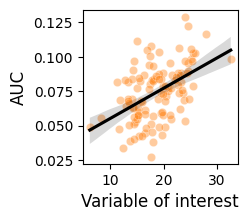

In [7]:
def plot_corr(mapconn, map, ax=None, color_obs="tab:orange", 
              title="", xlabel="Variable of interest", ylabel="AUC"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(2, 2))
    
    # data
    auc = mapconn.get_stats(maps=map)["auc"].values.squeeze()
    rng = np.random.default_rng(42)
    cov = auc * 120 + rng.normal(0, 5, len(auc)) + 10
    # plot observed/inverse
    sn.scatterplot(
        y=auc,
        x=cov,
        ax=ax,
        color=color_obs,
        alpha=0.4,
    )
    sn.regplot(
        y=auc,
        x=cov,
        ax=ax,
        color="k",
        scatter=False
    )
        
    # layout
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    
plot_corr(mfc_ya_mri["pearson"]["all"]["1"], "NET")

In [8]:

import matplotlib as mpl

def plot_parc_data(mapconn, map, ax=None, fig=None, threshold=None, cbar_label="PET density percentile",
                   views="LARS", cmap="viridis", voxelsize=1, inverted=False, cbar_side="right",
                   annotate=False):
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 2))
    ax.set_axis_off()
    
    if not inverted:
        data = mapconn.get_map_data(pct=True).loc[map]
    else:
        data = mapconn.get_observed().get_inverse().get_map_data(pct=True).loc[map]
    norm = mpl.colors.Normalize(vmin=0, vmax=100)
    cmap = sn.color_palette(cmap, as_cmap=True)
    colors = cmap(norm(data))
    if threshold is not None:
        colors[data < threshold] = np.nan
        
    ax_views = []
    x_prop = 1 / len(views)
    for i in range(len(views)):
        ax_views.append(ax.inset_axes((x_prop * i, 0, x_prop, 1), projection="3d"))
        
    netplotbrain.plot(
        nodes={
            'atlas': 'Schaefer2018',
            'desc': '200Parcels7Networks',
            'resolution': 1
        },
        template='MNI152NLin6Asym',
        template_style="glass",
        template_glass_maxalpha=0.02,
        view=views,
        node_type='parcels',
        node_alpha=0.8,
        node_color=colors,
        node_cmap=cmap,
        template_voxelsize=voxelsize,
        arrowaxis=None,
        subtitles=None,
        title=None,
        ax=ax_views,
        showlegend=False,
        fig=fig
    )
    
    if annotate:
        for ax_view, view in zip(ax_views, views):
            ax_view.annotate(
                {"L": "Left", "R": "Right", "S": "Superior", "I": "Inferior", "A": "Anterior"}[view],
                xy=(0.5, 0),
                xycoords="axes fraction",
                ha="center",
                va="center",
                fontsize=12
            )
    
    if cbar_side == "right":
        cax = ax.inset_axes([1.03, 0.2, 0.02, 0.6])
    else:
        cax = ax.inset_axes([-0.05, 0.2, 0.02, 0.6])
    #cmap = sn.color_palette(cmap, as_cmap=True)
    norm = mpl.colors.Normalize(vmin=0, vmax=100)
    cbar = plt.colorbar(
        mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cax,
        orientation="vertical"
    )
    cbar.set_label(cbar_label, fontsize=12)
    if cbar_side == "right":
        cbar.ax.yaxis.set_ticks_position("right")
        cbar.ax.yaxis.set_label_position("right")
    else:
        cbar.ax.yaxis.set_ticks_position("left")
        cbar.ax.yaxis.set_label_position("left")
    
    return ax


#plot_parc_data(mfc_ya_mri["pearson"]["all"]["1"], "NET")

In [9]:

def plot_connectivity(mapconn, map, ax=None, fig=None, threshold=None, cmap="vlag", 
                      voxelsize=1, edge_scale=2, max_edge_pct=98):
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(2, 2), subplot_kw={"projection": "3d"})
    ax.set_axis_off()
    
    data_edges = (
        mapconn.get_connectivity_matrices(flat=True)
        .apply(np.tanh)
        .mean()
        .to_frame(name="weight")
        .reset_index()
        .rename(columns={"parcelA": "i", "parcelB": "j"})
    )
    
    if threshold is not None:
        mask = mapconn.get_mappercentile_masks().loc[map].loc[threshold].T
        data_edges = data_edges[mask.values]
    
    if max_edge_pct is not None:
        edges_max = np.percentile(data_edges["weight"].abs(), max_edge_pct)
    else:
        edges_max = data_edges["weight"].abs().max()
    norm = mpl.colors.Normalize(vmin=-edges_max, vmax=edges_max, clip=True)
    norm_alpha = mpl.colors.Normalize(vmin=0, vmax=edges_max, clip=True)
    cmap = sn.color_palette(cmap, as_cmap=True)
    colors = cmap(norm(data_edges["weight"]))
    alphas = norm_alpha(data_edges["weight"].abs())
    colors[:, -1] = alphas
    
    netplotbrain.plot(
        nodes={
            'atlas': 'Schaefer2018',
            'desc': '200Parcels7Networks',
            'resolution': 1
        },
        template='MNI152NLin6Asym',
        template_style="glass",
        template_glass_maxalpha=0.02,
        view="S",
        node_type='circles',
        node_alpha=0.1,
        node_scale=20,
        node_color="k",
        edges=data_edges,
        #edge_alpha=0.2,
        edge_color=colors,
        edge_widthscale=edge_scale,
        #edge_weights="weight",
        template_voxelsize=voxelsize,
        arrowaxis=None,
        subtitles=None,
        title=None,
        ax=ax,
        showlegend=False,
        fig=fig,
    )
    
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False


#plot_connectivity(mfc_ya_mri["pearson"]["all"]["1"], "NET")

### Run

  0%|          | 0/21 [00:00<?, ?it/s]

/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/netplotbrain/plot.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/netplotbrain/plot.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_8546/1590915755.py:85: RuntimeWarning: Mean of empty slice
  matrix = np.tanh(np.nanmean(np.stack(matrix), axis=0))
/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/netplotbrain/plot.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/netplotbrain/plot.py:292: UserWarning: This figure includes Axes that are not compati

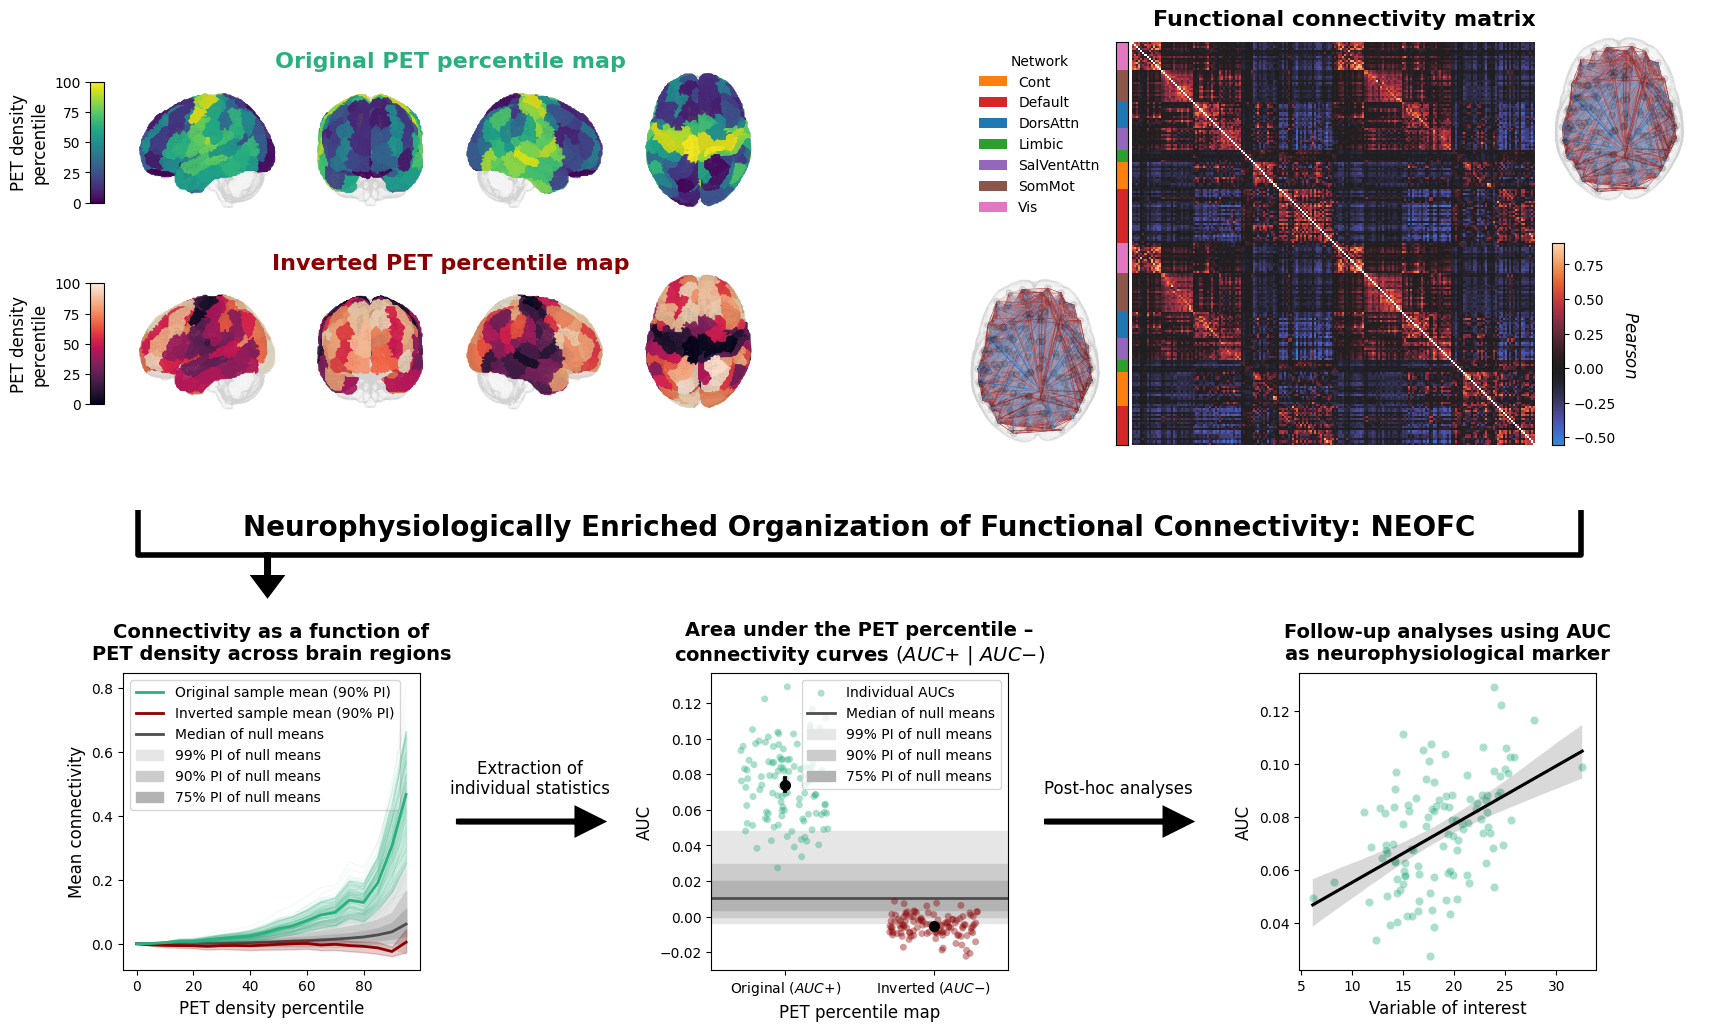

/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/netplotbrain/plot.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/netplotbrain/plot.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_8546/1590915755.py:85: RuntimeWarning: Mean of empty slice
  matrix = np.tanh(np.nanmean(np.stack(matrix), axis=0))
/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/netplotbrain/plot.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/netplotbrain/plot.py:292: UserWarning: This figure includes Axes that are not compati

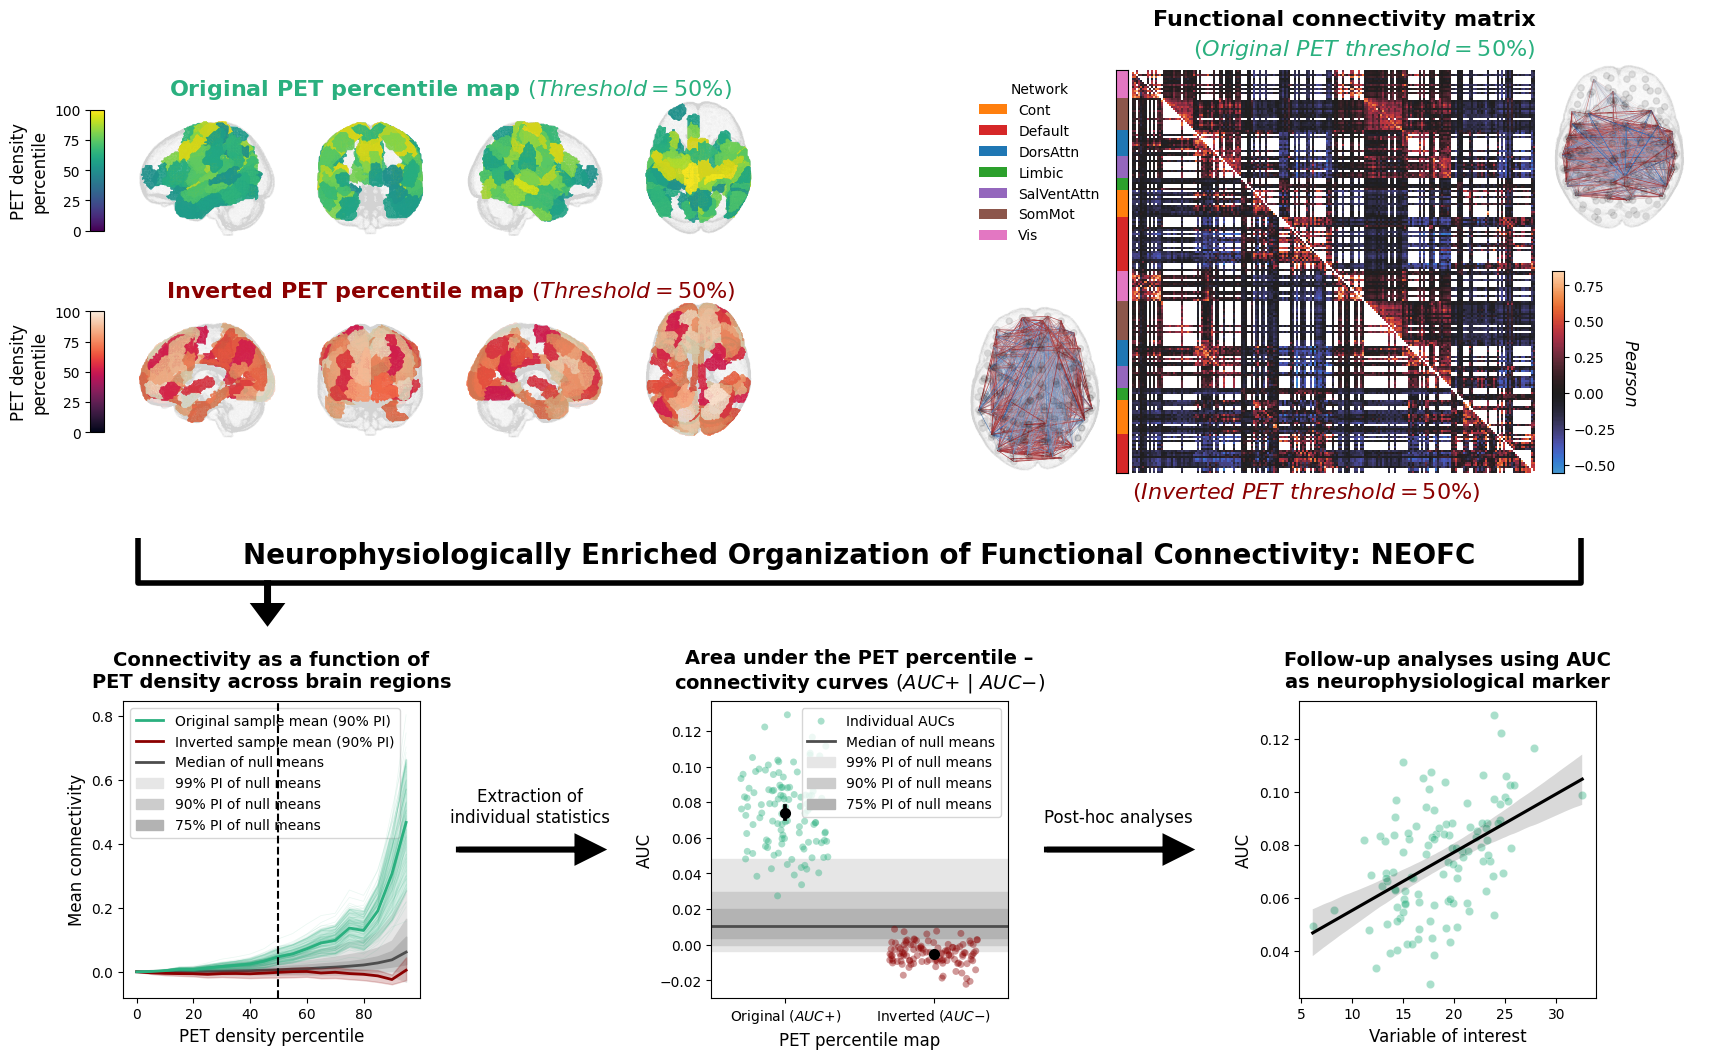

/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/netplotbrain/plot.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/netplotbrain/plot.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_8546/1590915755.py:85: RuntimeWarning: Mean of empty slice
  matrix = np.tanh(np.nanmean(np.stack(matrix), axis=0))
/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/netplotbrain/plot.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/netplotbrain/plot.py:292: UserWarning: This figure includes Axes that are not compati

In [10]:
m = "NET"
threshold_high_quality = [None, 50]
first_only = False # for testing
test_threshold = None # for testing
voxelsize = 1 # increase for testing
plot_brains = True # turn off for testing to save time
########################

for threshold in tqdm([None, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]):
    if first_only:
        if threshold is not None:
            continue
    elif test_threshold:
        if threshold != test_threshold:
            continue
    
    # create figure
    fig = plt.figure(figsize=(19, 13))
    gs0 = GridSpec(2, 2, hspace=0, wspace=0.5, bottom=0.57, width_ratios=[1, 0.8])
    gs1 = GridSpec(1, 5, wspace=0.1, top=0.45, width_ratios=[1, 0.8, 1, 0.8, 1]) 
    gs2 = GridSpec(1, 1, top=0.52, bottom=0.45)

    # PARCELLATION observed
    ax = plt.subplot(gs0[0, 0])
    if plot_brains:
        plot_parc_data(
            mapconn=mfc_ya_mri["pearson"]["all"]["1"],
            map=m,
            ax=ax,
            fig=fig,
            threshold=threshold,
            voxelsize=voxelsize,
            cbar_side="left",
            cmap="viridis",
            cbar_label="PET density\npercentile"
        )
    ax.annotate(
        f"Original PET percentile map" + (f" $(Threshold = {threshold}\%)$" if threshold is not None else ""),
        xy=(0.5, 0.9),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold",
        zorder=1000,
        color=sn.color_palette("viridis", 10)[-4]
    )
    
    # PARCELLATION inverse
    ax = plt.subplot(gs0[1, 0])
    if plot_brains:
        plot_parc_data(
            mapconn=mfc_ya_mri["pearson"]["all"]["1"],
            map=m,
            ax=ax,
            fig=fig,
            threshold=threshold,
            voxelsize=voxelsize,
            inverted=True,
            cbar_side="left",
            cmap="rocket",
            cbar_label="PET density\npercentile"
        )
    ax.annotate(
        f"Inverted PET percentile map" + (f" $(Threshold = {threshold}\%)$" if threshold is not None else ""),
        xy=(0.5, 0.9),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold",
        zorder=1000,
        color="darkred"
    )
    
    # MATRIX
    ax = plt.subplot(gs0[:, 1])
    ax.patch.set_alpha(0)
    ax.set_box_aspect(1)
    mask = mfc_ya_mri["pearson"]["all"]["1"].get_mappercentile_masks(flat=False) \
        .loc[(m, threshold if threshold is not None else 0)]
    mask_inverse = mfc_ya_mri["pearson"]["all"]["1"].get_observed().get_inverse().get_mappercentile_masks(flat=False) \
        .loc[(m, threshold if threshold is not None else 0)]
    matrix = mfc_ya_mri["pearson"]["all"]["1"].get_connectivity_matrices(flat=False)
    matrix = np.tanh(np.nanmean(np.stack(matrix), axis=0))
    matrix_observed, matrix_inverse = matrix.copy(), matrix.copy()
    matrix_observed[np.ix_(~mask, ~mask)] = np.nan
    matrix_inverse[np.ix_(~mask_inverse, ~mask_inverse)] = np.nan
    plot_matrix(
        matrix=matrix_inverse, matrix_upper=matrix_observed,
        ax=ax,
        x_label="$Pearson$",
        categories=[l.split("_")[1].replace("div-", "") for l in data_ref.columns],
    )
    #ax.set_title("Functional connectivity matrices", fontsize=14, fontweight="bold", pad=20)
    if threshold is None:     
        ax.annotate(
            "Functional connectivity matrix",
            xy=(1, 1.03),
            xycoords="axes fraction",
            ha="right",
            va="bottom",
            fontsize=16,
            fontweight="bold",
            zorder=1000
        )
    else:
        ax.annotate(
            "Functional connectivity matrix",
            xy=(1, 1.1),
            xycoords="axes fraction",
            ha="right",
            va="bottom",
            fontsize=16,
            fontweight="bold",
            zorder=1000
        )
        ax.annotate(
            f"$(Original\ PET\ threshold = {{{threshold}}}\%)$",
            xy=(1, 1.02),
            xycoords="axes fraction",
            ha="right",
            va="bottom",
            fontsize=16,
            fontweight="bold",
            zorder=1000,
            color=sn.color_palette("viridis", 10)[-4]
        )
        ax.annotate(
            f"$(Inverted\ PET\ threshold = {{{threshold}}}\%)$",
            xy=(0, -0.02),
            xycoords="axes fraction",
            ha="left",
            va="top",
            fontsize=16,
            fontweight="bold",
            zorder=1000,
            color="darkred"
        )
    
    
    # CONNECTIVITY OBSERVED
    ax_left = ax.inset_axes([-0.5, -0.1, 0.5, 0.6], projection="3d", zorder=-100)
    ax_right = ax.inset_axes([0.95, 0.5, 0.5, 0.6], projection="3d", zorder=-100)
    if plot_brains:
        for ax, data in [(ax_left, mfc_ya_mri["pearson"]["all"]["1"].get_observed().get_inverse()),
                         (ax_right, mfc_ya_mri["pearson"]["all"]["1"]) ]:
            ax.set_axis_off()
            plot_connectivity(
                mapconn=data,
                map="NET",
                ax=ax,
                fig=fig,
                threshold=threshold,
                edge_scale=1,
                voxelsize=voxelsize,
                max_edge_pct=95
            )
        
    # MAPCONN
    ax = plt.subplot(gs1[0, 0])
    ax.set_box_aspect(1)
    plot_mapconn(
        mapconn=mfc_ya_mri["pearson"]["all"]["1"],
        map=m,
        ax=ax,
        color_obs=sn.color_palette("viridis", 10)[-4],
    )
    ax.set_title("Connectivity as a function of\nPET density across brain regions", fontsize=14, fontweight="bold", pad=10)
    handles, labels = ax.get_legend_handles_labels()
    handles_order = [5, 0, 1, 2, 3, 4]
    labels = [labels[i] for i in handles_order]
    labels[0] = "Original sample mean (90% PI)"
    labels[1] = "Inverted sample mean (90% PI)"
    ax.legend([handles[i] for i in handles_order], labels,
              loc="upper left")
    
    # curve vertical line
    if threshold is not None:
        ax.axvline(x=threshold, color="k", linestyle="--", alpha=1, zorder=1000)

    # bracket
    plot_pos = 0.09
    ax = plt.subplot(gs2[0, 0])
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(0, 1)
    ax.set_axis_off()
    ax.plot([0, 0, 1, 1], 
            [1, 0.5, 0.5, 1],
            c="k", lw=4)
    ax.arrow(plot_pos, 0.5, 0, -0.25, head_width=0.017, head_length=0.18, lw=4, fc="k", ec="k")
    ax.text(
        s="Neurophysiologically Enriched Organization of Functional Connectivity: NEOFC",
        x=0.5,
        y=0.65,
        va="bottom", ha="center",
        weight="bold",
        size=20,
    )

    # AUC
    ax = plt.subplot(gs1[0, 2])
    ax.set_box_aspect(1)
    plot_auc(
        mapconn=mfc_ya_mri["pearson"]["all"]["1"],
        map=m,
        ax=ax,
        color_obs=sn.color_palette("viridis", 10)[-4],
    )
    ax.set_title("Area under the PET percentile –\nconnectivity curves $(AUC\t{+}\ |\ AUC\t{-})$", fontsize=14, fontweight="bold", pad=10)
    handles, labels = ax.get_legend_handles_labels()
    handles_order = [0, 5, 2, 3, 4]
    ax.legend([handles[i] for i in handles_order], [labels[i] for i in handles_order],
            loc="upper right")
    
    # arrow
    ax = plt.subplot(gs1[0, 1])
    ax.set_box_aspect(1)
    ax.set_axis_off()
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 1)
    ax.arrow(0.05, 0.5, 0.5, 0, head_width=0.1, head_length=0.1, lw=4, fc="k", ec="k")
    ax.annotate("Extraction of\nindividual statistics", xy=(0.35, 0.6), xycoords="data",
                ha="center", va="bottom", fontsize=12)
    
    # association
    ax = plt.subplot(gs1[0, 4])
    ax.set_box_aspect(1)
    plot_corr(
        mapconn=mfc_ya_mri["pearson"]["all"]["1"],
        map=m,
        ax=ax,
        color_obs=sn.color_palette("viridis", 10)[-4],
    )
    ax.set_title("Follow-up analyses using AUC\nas neurophysiological marker", fontsize=14, fontweight="bold", pad=10)

    # arrow
    ax = plt.subplot(gs1[0, 3])
    ax.set_box_aspect(1)
    ax.set_axis_off()
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 1)
    ax.arrow(0.05, 0.5, 0.5, 0, head_width=0.1, head_length=0.1, lw=4, fc="k", ec="k")
    ax.annotate("Post-hoc analyses", xy=(0.35, 0.6), xycoords="data",
                ha="center", va="bottom", fontsize=12)
    
    

    if threshold in threshold_high_quality:
        fig.savefig(wd / "plots" / "method_overview" / f"overview_ref-{m}_thresh-{threshold}.jpg", dpi=250, bbox_inches="tight")
        fig.savefig(wd / "plots" / "method_overview" / f"overview_ref-{m}_thresh-{threshold}.png", dpi=400, bbox_inches="tight")
        plt.show()
    else:
        fig.savefig(wd / "plots" / "method_overview" / f"overview_ref-{m}_thresh-{threshold}.jpg", dpi=250, bbox_inches="tight")
        #plt.show() # remove
    plt.close()


### Create animation

In [11]:
for m in data_ref.index:

    files = [
        wd / "plots" / "method_overview" / f"overview_ref-{m}_thresh-{threshold}.jpg" 
        for threshold in [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
    ]
    
    if all(f.exists() for f in files):
        print(f"Creating gif for {m}")
        imgs = [iio.imread(f) for f in files]
        iio.mimwrite(wd / "plots" / "method_overview" / f"overview_ref-{m}.gif", imgs, fps=1)

Creating gif for NET


## Simple connectivity matrix

In [12]:
# fig, ax = plt.subplots(figsize=(4, 4))
# sn.heatmap(
#     np.tanh(np.mean(mfc_ya_mri["pet_pearsoncorrelation"]["obs"].get_connectivity_matrices(flat=False), axis=0)),
#     center=0,
#     cmap="icefire",
#     cbar=False,
#     square=True,
#     xticklabels=False,
#     yticklabels=False,
# )
# ax.set_xlabel("Regions", fontsize=14, fontweight="bold")
# ax.set_ylabel("Regions", fontsize=14, fontweight="bold")
# plt.savefig(wd / "plots" / "method_overview" / "simple_conn_matrix.png", dpi=800, bbox_inches="tight")


## Simple connectome

In [13]:
# fig = plt.figure(figsize=(10, 4))
# gs = fig.add_gridspec(1, 4, wspace=0)
# axes = [fig.add_subplot(gs[0, i], projection="3d") for i in range(4)]

# data = pd.DataFrame(
#     np.mean(np.tanh(mfc_ya_mri["pet_pearsoncorrelation"]["obs"].get_connectivity_matrices(flat=True)), axis=0),
#     columns=["weight"]
# )
# data.index.names = ["i", "j"]
# data = data.reset_index()
# data = data[data.weight > 0.3]

# norm = mpl.colors.Normalize(vmin=0.3, vmax=1)
# cmap = sn.color_palette("rocket", as_cmap=True)
# colors = cmap(norm(data["weight"]))

# norm_alpha = mpl.colors.Normalize(vmin=0.3, vmax=1)
# alphas = norm_alpha(data["weight"].abs())
# colors[:, -1] = alphas

# netplotbrain.plot(
#     nodes={
#         'atlas': 'Schaefer2018',
#         'desc': '200Parcels7Networks',
#         'resolution': 1
#     },
#     template="MNI152NLin6Asym",
#     template_style="glass",
#     template_glass_maxalpha=0.02,
#     view="LARS",
#     node_type='circles',
#     node_alpha=0.1,
#     node_scale=20,
#     node_color="k",
#     edges=data,
#     edge_color=colors,
#     edge_widthscale=1,
#     template_voxelsize=1,
#     arrowaxis=None,
#     subtitles=None,
#     title=None,
#     ax=axes,
#     showlegend=False,
#     fig=fig,
# )

# plt.savefig(wd / "plots" / "method_overview" / "simple_connectome.png", dpi=300, bbox_inches="tight")

## Simple PET map

In [14]:
# for m in ["VAChT", "NET"]:

#     fig = plt.figure(figsize=(10, 4))
#     gs = fig.add_gridspec(1, 4, wspace=0)
#     axes = [fig.add_subplot(gs[0, i], projection="3d") for i in range(4)]

#     data = mfc_ya_mri["pet_pearsoncorrelation"]["obs"].get_map_data(pct=True).loc[m]

#     norm = mpl.colors.Normalize(vmin=0, vmax=100)
#     cmap = sn.color_palette("viridis", as_cmap=True)
#     colors = cmap(norm(data))

#     netplotbrain.plot(
#         nodes={
#             'atlas': 'Schaefer2018',
#             'desc': '200Parcels7Networks',
#             'resolution': 1
#         },
#         template="MNI152NLin6Asym",
#         template_style="glass",
#         template_glass_maxalpha=0.02,
#         view="LARS",
#         node_type='parcels',
#         node_color=colors,
#         template_voxelsize=1,
#         arrowaxis=None,
#         subtitles=None,
#         title=None,
#         ax=axes,
#         showlegend=False,
#         fig=fig,
#     )

#     plt.savefig(wd / "plots" / "method_overview" / f"simple_pet_map_{m}.png", dpi=300, bbox_inches="tight")

